After extracting the structures of the two subunit from PDB bank (`sub1.pdb` and `sub2.pdb` in the context, which are not uploaded here), this script is run to get the rotation center

In [2]:
import numpy as np

In [8]:
def xyz(filein, n):
    xyz = []
    with open(filein, 'r') as fin:
        for line in fin:
            if line.startswith("ATOM") and len(xyz) < n:
                x = float(line[30:38].strip())  # X coordinate
                y = float(line[38:46].strip())  # Y coordinate
                z = float(line[46:54].strip())  # Z coordinate
                xyz.append([x, y, z])
    return np.array(xyz)
            

Read the first 10000 (can be any arbitrary number) atoms and get the x and y coordinated. The z coordinate has been confirmed to remain the same in the rotation which means the rotation is along the z axis

In [50]:
xyz_1 = xyz("sub1.pdb", 10000)
xyz_2 = xyz("sub2.pdb", 10000)

xy_1 = xyz_1[:, :2]
xy_2 = xyz_2[:, :2]

In [55]:
# Rotate subunit 1 counterclockwise gives subunit 2
# Rotate counterclockwise around the z-axis by 45 degrees, right multiplied
A = np.array([np.cos(np.pi/4), np.sin(np.pi/4), -np.sin(np.pi/4), np.cos(np.pi/4)]).reshape(2, 2)

In [56]:
B = np.linalg.inv(A - np.eye(2))

In [57]:
# Rotation center
c = (xy_1@A - xy_2)@B

The unit is Angstrom

In [63]:
c.mean(axis=0)

array([993.59997797, 993.5999673 ])

In [39]:
import matplotlib.pyplot as plt

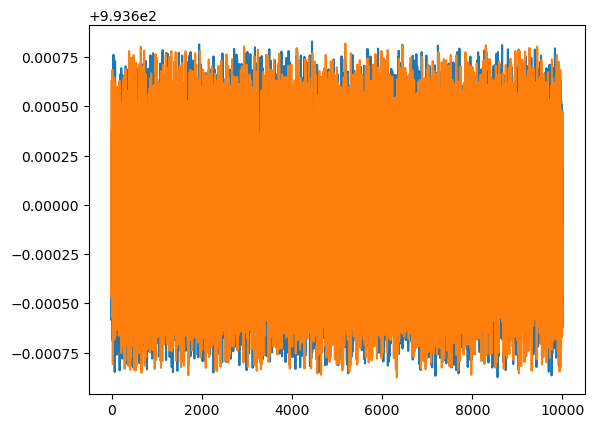

In [58]:
plt.plot(c)